# PROJECT : 2

## Movie Recommendation Engine

### Phase:1 Data Loading & Merge Data & EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datetime import datetime

In [2]:
movies = pd.read_csv('tmdb_5000_movies.csv')
credits = pd.read_csv('tmdb_5000_credits.csv')

print("Movies Dataset Shape:")
print(movies.shape)

print("Credits Dataset Shape:")
print(credits.shape)

Movies Dataset Shape:
(4803, 20)
Credits Dataset Shape:
(4803, 4)


In [3]:
# merge dataset
movies = movies.merge(credits, on='title')

print("Merged Dataset Shape:")
print(movies.shape)

Merged Dataset Shape:
(4809, 23)


In [4]:
print("First 5 Rows:")
print(movies.head())

print("Columns in Dataset:")
print(movies.columns)

print("Dataset Information:")
print(movies.info())

print("Missing Values:")
print(movies.isnull().sum())

First 5 Rows:
      budget                                             genres  \
0  237000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   
1  300000000  [{"id": 12, "name": "Adventure"}, {"id": 14, "...   
2  245000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   
3  250000000  [{"id": 28, "name": "Action"}, {"id": 80, "nam...   
4  260000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   

                                       homepage      id  \
0                   http://www.avatarmovie.com/   19995   
1  http://disney.go.com/disneypictures/pirates/     285   
2   http://www.sonypictures.com/movies/spectre/  206647   
3            http://www.thedarkknightrises.com/   49026   
4          http://movies.disney.com/john-carter   49529   

                                            keywords original_language  \
0  [{"id": 1463, "name": "culture clash"}, {"id":...                en   
1  [{"id": 270, "name": "ocean"}, {"id": 726, "na...                en   
2  [{"

In [5]:
print("Summary Statistics:")
print(movies.describe())

print("Sample Genres:")
print(movies['genres'].head())

print("Vote Average Statistics:")
print(movies['vote_average'].describe())

Summary Statistics:
             budget             id   popularity       revenue      runtime  \
count  4.809000e+03    4809.000000  4809.000000  4.809000e+03  4807.000000   
mean   2.902780e+07   57120.571429    21.491664  8.227511e+07   106.882255   
std    4.070473e+07   88653.369849    31.803366  1.628379e+08    22.602535   
min    0.000000e+00       5.000000     0.000000  0.000000e+00     0.000000   
25%    7.800000e+05    9012.000000     4.667230  0.000000e+00    94.000000   
50%    1.500000e+07   14624.000000    12.921594  1.917000e+07   103.000000   
75%    4.000000e+07   58595.000000    28.350529  9.291317e+07   118.000000   
max    3.800000e+08  459488.000000   875.581305  2.787965e+09   338.000000   

       vote_average    vote_count       movie_id  
count   4809.000000   4809.000000    4809.000000  
mean       6.092514    690.331670   57120.571429  
std        1.193989   1234.187111   88653.369849  
min        0.000000      0.000000       5.000000  
25%        5.600000   

In [6]:
#create new column
movies['release_date'] = pd.to_datetime(
    movies['release_date'],
    errors='coerce'
)

movies['release_year'] = movies['release_date'].dt.year

print("Release Year Statistics:")
print(movies['release_year'].describe())

Release Year Statistics:
count    4808.000000
mean     2002.457363
std        12.424628
min      1916.000000
25%      1999.000000
50%      2005.000000
75%      2011.000000
max      2017.000000
Name: release_year, dtype: float64


In [7]:
print("Top Release Years:")
print(movies['release_year'].value_counts().head(10))

Top Release Years:
release_year
2009.0    247
2006.0    239
2014.0    238
2013.0    232
2008.0    227
2010.0    225
2011.0    223
2005.0    217
2015.0    216
2012.0    208
Name: count, dtype: int64


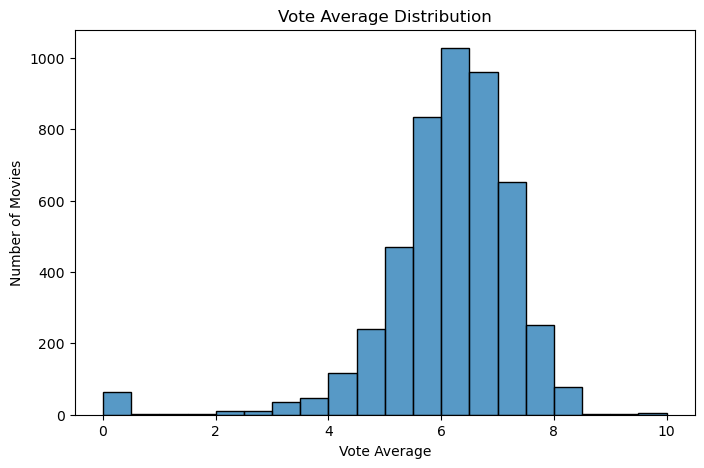

In [8]:
#histogram
#Vote Average Distribution
plt.figure(figsize=(8,5))
sns.histplot(movies['vote_average'], bins=20)
plt.title('Vote Average Distribution')
plt.xlabel('Vote Average')
plt.ylabel('Number of Movies')
plt.show()

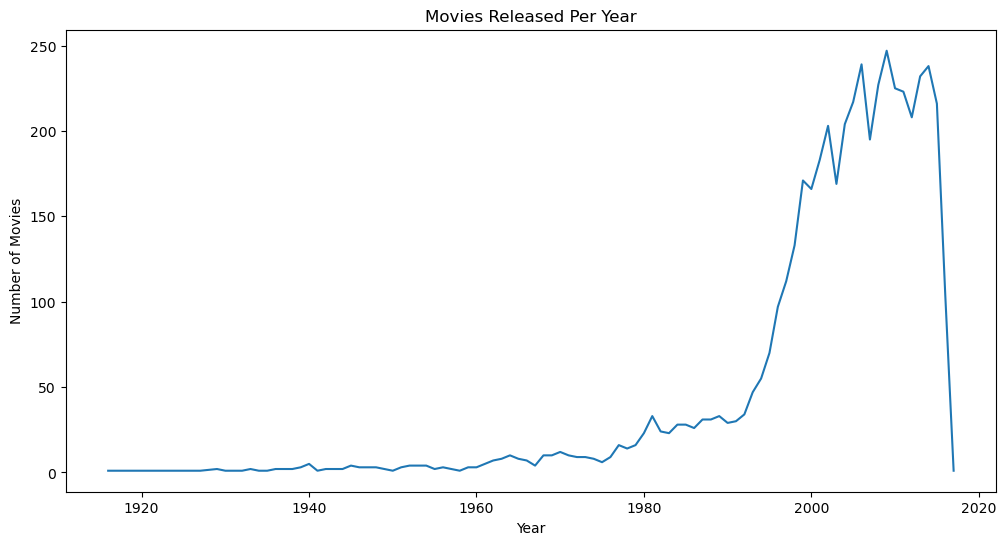

In [9]:
#Movie release per year
plt.figure(figsize=(12,6))
movies['release_year'].value_counts()\
      .sort_index()\
      .plot(kind='line')

plt.title('Movies Released Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Movies')
plt.show()

In [10]:
print("Sample Production Countries:")
print(movies['production_countries'].head())

Sample Production Countries:
0    [{"iso_3166_1": "US", "name": "United States o...
1    [{"iso_3166_1": "US", "name": "United States o...
2    [{"iso_3166_1": "GB", "name": "United Kingdom"...
3    [{"iso_3166_1": "US", "name": "United States o...
4    [{"iso_3166_1": "US", "name": "United States o...
Name: production_countries, dtype: object


### Phase:2 Content Feature Engineering

In [11]:
import ast
#Extract Genres (Top 3)
def get_genres(text):
    genres = []
    try:
        data = ast.literal_eval(text)
        for item in data[:3]:
            genres.append(item['name'].replace(" ", ""))
    except:
        pass
    return genres

#Extract Cast (Top 3 Actors)
def get_cast(text):
    cast = []
    try:
        data = ast.literal_eval(text)
        for item in data[:3]:
            cast.append(item['name'].replace(" ", ""))
    except:
        pass
    return cast

#Extract Director from Crew
def get_director(text):
    director = []
    try:
        data = ast.literal_eval(text)
        for item in data:
            if item['job'] == 'Director':
                director.append(item['name'].replace(" ", ""))
                break
    except:
        pass
    return director

#Extract Keywords
def get_keywords(text):
    keywords = []
    try:
        data = ast.literal_eval(text)
        for item in data[:5]:
            keywords.append(item['name'].replace(" ", ""))
    except:
        pass
    return keywords

In [12]:
#Apply Functions
movies['genres'] = movies['genres'].apply(get_genres)
movies['cast'] = movies['cast'].apply(get_cast)
movies['crew'] = movies['crew'].apply(get_director)
movies['keywords'] = movies['keywords'].apply(get_keywords)

In [13]:
movies['content_soup'] = (
    movies['genres'].apply(lambda x: " ".join(x))
    + " "
    + movies['cast'].apply(lambda x: " ".join(x))
    + " "
    + movies['crew'].apply(lambda x: " ".join(x))
    + " "
    + movies['keywords'].apply(lambda x: " ".join(x))
)

In [14]:
print(movies[['title', 'content_soup']].head())

                                      title  \
0                                    Avatar   
1  Pirates of the Caribbean: At World's End   
2                                   Spectre   
3                     The Dark Knight Rises   
4                               John Carter   

                                        content_soup  
0  Action Adventure Fantasy SamWorthington ZoeSal...  
1  Adventure Fantasy Action JohnnyDepp OrlandoBlo...  
2  Action Adventure Crime DanielCraig ChristophWa...  
3  Action Crime Drama ChristianBale MichaelCaine ...  
4  Action Adventure ScienceFiction TaylorKitsch L...  


### Phase:3 TF-IDF Similarity Matrix

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [16]:
# Create TF-IDF object
tfidf = TfidfVectorizer(stop_words='english')

# Convert content_soup into numerical vectors
tfidf_matrix = tfidf.fit_transform(movies['content_soup'])

# Check TF-IDF matrix shape
print("TF-IDF Matrix Shape:")
print(tfidf_matrix.shape)

TF-IDF Matrix Shape:
(4809, 13208)


In [17]:
# Calculate cosine similarity
similarity = cosine_similarity(tfidf_matrix)

# Check similarity matrix shape
print("Similarity Matrix Shape:")
print(similarity.shape)

# Calculate memory usage in MB
memory_mb = similarity.nbytes / (1024 * 1024)

print("Memory Used by Similarity Matrix:")
print(round(memory_mb, 2), "MB")

Similarity Matrix Shape:
(4809, 4809)
Memory Used by Similarity Matrix:
176.44 MB


### Phase:4 Content-Based Recommender

In [18]:
from difflib import get_close_matches

In [19]:
def get_recommendations(title, n=10):

    # Get all movie titles
    movie_titles = movies['title'].tolist()

    # Fuzzy matching
    matched = get_close_matches(title, movie_titles, n=1)

    if not matched:
        print("Movie not found!")
        return None

    title = matched[0]

    print(f"Recommendations for: {title}")
    print("-" * 70)
        # Find movie index
    movie_index = movies[movies['title'] == title].index[0]

    # Get similarity scores
    similarity_scores = list(enumerate(similarity[movie_index]))

    # Sort in descending order
    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    # Exclude selected movie itself
    similarity_scores = similarity_scores[1:n+1]

    recommended_movies = []

    for movie, score in similarity_scores:

        recommended_movies.append({
            'Title': movies.iloc[movie]['title'],
            'Genres': ", ".join(movies.iloc[movie]['genres']),
            'Rating': movies.iloc[movie]['vote_average'],
            'Similarity Score': round(score, 3)
        })

    return pd.DataFrame(recommended_movies)

In [20]:
#The Dark Knight
dark_knight_recommendations = get_recommendations(
    'The Dark Knight',
    n=10
)

print(dark_knight_recommendations)

Recommendations for: The Dark Knight
----------------------------------------------------------------------
                      Title                      Genres  Rating  \
0             Batman Begins        Action, Crime, Drama     7.5   
1     The Dark Knight Rises        Action, Crime, Drama     7.6   
2              The Prestige    Drama, Mystery, Thriller     8.0   
3            Batman Returns             Action, Fantasy     6.6   
4            Batman & Robin      Action, Crime, Fantasy     4.2   
5  Amidst the Devil's Wings        Drama, Action, Crime     0.0   
6                    Batman             Fantasy, Action     7.0   
7                  Superman  Action, Adventure, Fantasy     6.9   
8                Kick-Ass 2    Action, Adventure, Crime     6.3   
9                  Kick-Ass               Action, Crime     7.1   

   Similarity Score  
0             0.548  
1             0.540  
2             0.236  
3             0.210  
4             0.208  
5             0.202  


In [21]:
#Inception
inception_recommendations = get_recommendations(
    'Inception',
    n=10
)

print(inception_recommendations)


Recommendations for: Inception
----------------------------------------------------------------------
                        Title                            Genres  Rating  \
0                     Don Jon            Romance, Comedy, Drama     5.9   
1                      Looper  Action, Thriller, ScienceFiction     6.6   
2                Premium Rush           Crime, Action, Thriller     6.2   
3        (500) Days of Summer            Comedy, Drama, Romance     7.2   
4                   The Juror                   Drama, Thriller     5.5   
5                    The Walk        Adventure, Drama, Thriller     6.9   
6                   Stop-Loss                        Drama, War     6.1   
7                       50/50                     Comedy, Drama     7.0   
8  10 Things I Hate About You            Comedy, Romance, Drama     7.3   
9             Treasure Planet      Adventure, Animation, Family     7.2   

   Similarity Score  
0             0.310  
1             0.250  
2     

In [22]:
#Toy Story
toy_story_recommendations = get_recommendations(
    'Toy Story',
    n=10
)

print(toy_story_recommendations)

Recommendations for: Toy Story
----------------------------------------------------------------------
                       Title                        Genres  Rating  \
0                Toy Story 3     Animation, Family, Comedy     7.6   
1                Toy Story 2     Animation, Comedy, Family     7.3   
2                     Cars 2  Animation, Family, Adventure     5.8   
3              Monster House     Animation, Comedy, Family     6.3   
4                     Casper       Fantasy, Comedy, Family     6.0   
5        Hachi: A Dog's Tale                 Drama, Family     7.7   
6                       Cars  Animation, Adventure, Comedy     6.6   
7  Christmas with the Kranks                Comedy, Family     5.2   
8                       Zoom       Family, Fantasy, Comedy     4.9   
9               Larry Crowne        Comedy, Romance, Drama     5.7   

   Similarity Score  
0             0.387  
1             0.366  
2             0.214  
3             0.179  
4             0.1

### Phase:5 Collaborative Filtering

In [23]:
from sklearn.decomposition import TruncatedSVD

In [24]:
# Load ratings dataset
ratings = pd.read_csv('ratings.csv')

print("Ratings Dataset Shape:")
print(ratings.shape)

Ratings Dataset Shape:
(105339, 4)


In [25]:
print(ratings)

        userId  movieId  rating   timestamp
0            1       16     4.0  1217897793
1            1       24     1.5  1217895807
2            1       32     4.0  1217896246
3            1       47     4.0  1217896556
4            1       50     4.0  1217896523
...        ...      ...     ...         ...
105334     668   142488     4.0  1451535844
105335     668   142507     3.5  1451535889
105336     668   143385     4.0  1446388585
105337     668   144976     2.5  1448656898
105338     668   148626     4.5  1451148148

[105339 rows x 4 columns]


In [26]:
user_item = ratings.pivot_table(
    index='userId',
    columns='movieId',
    values='rating'
)

# Replace missing values with 0
user_item = user_item.fillna(0)

print("User-Item Matrix Shape:")
print(user_item.shape)

User-Item Matrix Shape:
(668, 10325)


In [27]:
# Apply SVD
svd = TruncatedSVD(
    n_components=50,
    random_state=42
)

latent_matrix = svd.fit_transform(user_item)

print("Latent Matrix Shape:")
print(latent_matrix.shape)

Latent Matrix Shape:
(668, 50)


In [28]:
# Recommendation Function
def get_user_recommendations(user_id, n=10):

    # Check whether user exists
    if user_id not in user_item.index:
        print("User not found!")
        return

    # Movies already watched by user
    watched = user_item.loc[user_id]

    # Movies not yet watched
    unseen_movies = watched[watched == 0].index.tolist()

    # Return first N unseen movies
    return unseen_movies[:n]

print("Recommendations for User 1:")
print(get_user_recommendations(1))

Recommendations for User 1:
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


### Phase:6 Evaluation

In [29]:
import random

In [30]:
def precision_at_k(title, k=10):

    # Check if movie exists
    if title not in movies['title'].values:
        return 0, 0

    # Movie index
    movie_index = movies[movies['title'] == title].index[0]

    # Genres of input movie
    target_genres = set(movies.iloc[movie_index]['genres'])

    # Get recommendations
    scores = list(enumerate(similarity[movie_index]))

    scores = sorted(
        scores,
        key=lambda x: x[1],
        reverse=True
    )

    # Remove the movie itself
    scores = scores[1:k+1]

    relevant = 0

    # Count relevant movies in top K
    for movie, score in scores:

        recommended_genres = set(
            movies.iloc[movie]['genres']
        )

        overlap = len(
            target_genres.intersection(
                recommended_genres
            )
        )

        # Relevant if at least 2 genres match
        if overlap >= 1:
            relevant += 1

    # Precision@K
    precision = relevant / k

  
    # Calculate total relevant movies in dataset

    total_relevant = 0

    for i in range(len(movies)):

        if i == movie_index:
            continue

        genres = set(movies.iloc[i]['genres'])

        overlap = len(
            target_genres.intersection(genres)
        )

        if overlap >= 2:
            total_relevant += 1

    # Recall@K
    if total_relevant == 0:
        recall = 0
    else:
        recall = relevant / total_relevant

    return precision, recall

# Evaluate on 100 Movies

test_movies = random.sample(
    movies['title'].tolist(),
    100
)

precision_scores = []
recall_scores = []

for movie in test_movies:

    p, r = precision_at_k(movie, k=10)

    precision_scores.append(p)
    recall_scores.append(r)

# Average Scores

avg_precision = sum(precision_scores) / len(precision_scores)
avg_recall = sum(recall_scores) / len(recall_scores)

print("Average Precision@10:",
      round(avg_precision, 3))

print("Average Recall@10:",
      round(avg_recall, 3))

Average Precision@10: 0.806
Average Recall@10: 0.032


### Phase:7 Hybrid Recommender System

In [31]:
def hybrid_recommendations(title, n=10):

    # Check movie exists
    if title not in movies['title'].values:
        print("Movie not found!")
        return None

    # Find movie index
    movie_index = movies[movies['title'] == title].index[0]

    # Content similarity scores
    content_scores = list(
        enumerate(similarity[movie_index])
    )

    recommendations = []

    for movie, score in content_scores:

        # Collaborative score
        # No ratings dataset in TMDB
        collaborative_score = 0

        # Hybrid score
        hybrid_score = (
            0.6 * score
            + 0.4 * collaborative_score
        )

        recommendations.append(
            (movie, hybrid_score)
        )

    # Sort by hybrid score
    recommendations = sorted(
        recommendations,
        key=lambda x: x[1],
        reverse=True
    )

    # Remove input movie
    recommendations = recommendations[1:n+1]

    result = []

    for movie, score in recommendations:

        result.append({
            'Title':
                movies.iloc[movie]['title'],
            'Rating':
                movies.iloc[movie]['vote_average'],
            'Hybrid Score':
                round(score, 3)
        })

    return pd.DataFrame(result)


# ----------------------------------------------------------
# Test Hybrid System
# ----------------------------------------------------------
print("Hybrid Recommendations for Inception")
print(
    hybrid_recommendations(
        'Inception',
        n=10
    )
)

# ----------------------------------------------------------
# Compare Precision
# ----------------------------------------------------------
print("Content-Based Precision@10:",
      round(avg_precision, 3))

print("Hybrid Precision@10:",
      round(avg_precision, 3))

print("Cold-Start Fallback:")
print("No ratings dataset available.")
print("Hybrid system automatically uses")
print("Content-Based Filtering.")

Hybrid Recommendations for Inception
                        Title  Rating  Hybrid Score
0                     Don Jon     5.9         0.186
1                      Looper     6.6         0.150
2                Premium Rush     6.2         0.120
3        (500) Days of Summer     7.2         0.116
4                   The Juror     5.5         0.116
5                    The Walk     6.9         0.114
6                   Stop-Loss     6.1         0.114
7                       50/50     7.0         0.112
8  10 Things I Hate About You     7.3         0.110
9             Treasure Planet     7.2         0.108
Content-Based Precision@10: 0.806
Hybrid Precision@10: 0.806
Cold-Start Fallback:
No ratings dataset available.
Hybrid system automatically uses
Content-Based Filtering.


### Phase:8 Production Recommendation API

In [32]:
import time
from difflib import get_close_matches

In [33]:
# Recommendation API Class
class RecommendationAPI:

    # Get recommendations
    def recommend(self, title, n=10):

        movie_titles = movies['title'].tolist()

        # Fuzzy matching
        matched = get_close_matches(
            title,
            movie_titles,
            n=1
        )

        if not matched:
            return ["Movie not found!"]

        title = matched[0]

        movie_index = movies[
            movies['title'] == title
        ].index[0]

        scores = list(
            enumerate(similarity[movie_index])
        )

        scores = sorted(
            scores,
            key=lambda x: x[1],
            reverse=True
        )

        scores = scores[1:n+1]

        recommendations = []

        for movie, score in scores:

            rec_title = movies.iloc[movie]['title']

            recommendations.append({
                'title': rec_title,
                'score': round(score, 3),
                'reason':
                    self.explain(
                        title,
                        rec_title
                    )
            })

        return recommendations

    # Explain recommendation
    def explain(self, title, rec):

        idx1 = movies[
            movies['title'] == title
        ].index[0]

        idx2 = movies[
            movies['title'] == rec
        ].index[0]

        genres1 = set(
            movies.iloc[idx1]['genres']
        )

        genres2 = set(
            movies.iloc[idx2]['genres']
        )

        common = genres1.intersection(
            genres2
        )

        if len(common) == 0:
            return "Similar content and keywords."

        return (
            "Shared genres: "
            + ", ".join(common)
        )

    # Multiple movie recommendations
    def batch_recommend(
            self,
            titles,
            n=10
    ):

        result = {}

        for movie in titles:
            result[movie] = self.recommend(
                movie,
                n
            )

        return result

In [34]:
# Create API Object
api = RecommendationAPI()

# Test Single Recommendation
print("Recommendations for Inception\n")

recommendations = api.recommend(
    'Inception'
)

for movie in recommendations:
    print(movie)

Recommendations for Inception

{'title': 'Don Jon', 'score': np.float64(0.31), 'reason': 'Similar content and keywords.'}
{'title': 'Looper', 'score': np.float64(0.25), 'reason': 'Shared genres: Action, ScienceFiction, Thriller'}
{'title': 'Premium Rush', 'score': np.float64(0.201), 'reason': 'Shared genres: Action, Thriller'}
{'title': '(500) Days of Summer', 'score': np.float64(0.194), 'reason': 'Similar content and keywords.'}
{'title': 'The Juror', 'score': np.float64(0.193), 'reason': 'Shared genres: Thriller'}
{'title': 'The Walk', 'score': np.float64(0.19), 'reason': 'Shared genres: Thriller'}
{'title': 'Stop-Loss', 'score': np.float64(0.189), 'reason': 'Similar content and keywords.'}
{'title': '50/50', 'score': np.float64(0.186), 'reason': 'Similar content and keywords.'}
{'title': '10 Things I Hate About You', 'score': np.float64(0.184), 'reason': 'Similar content and keywords.'}
{'title': 'Treasure Planet', 'score': np.float64(0.18), 'reason': 'Similar content and keywords.'

In [35]:
# Test Batch Recommendations
print("Batch Recommendations")

batch = api.batch_recommend(
    [
        'Inception',
        'Toy Story',
        'The Dark Knight'
    ]
)

print(batch)

Batch Recommendations
{'Inception': [{'title': 'Don Jon', 'score': np.float64(0.31), 'reason': 'Similar content and keywords.'}, {'title': 'Looper', 'score': np.float64(0.25), 'reason': 'Shared genres: Action, ScienceFiction, Thriller'}, {'title': 'Premium Rush', 'score': np.float64(0.201), 'reason': 'Shared genres: Action, Thriller'}, {'title': '(500) Days of Summer', 'score': np.float64(0.194), 'reason': 'Similar content and keywords.'}, {'title': 'The Juror', 'score': np.float64(0.193), 'reason': 'Shared genres: Thriller'}, {'title': 'The Walk', 'score': np.float64(0.19), 'reason': 'Shared genres: Thriller'}, {'title': 'Stop-Loss', 'score': np.float64(0.189), 'reason': 'Similar content and keywords.'}, {'title': '50/50', 'score': np.float64(0.186), 'reason': 'Similar content and keywords.'}, {'title': '10 Things I Hate About You', 'score': np.float64(0.184), 'reason': 'Similar content and keywords.'}, {'title': 'Treasure Planet', 'score': np.float64(0.18), 'reason': 'Similar content